1. Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

2. Carga de datasets

In [2]:
ruta_train = "../../data/processed/Split_Datasets/data_train_clean.csv"
ruta_val   = "../../data/processed/Split_Datasets/data_val_clean.csv"
ruta_test  = "../../data/processed/Split_Datasets/data_test_clean.csv"

train_df = pd.read_csv(
    ruta_train,
    parse_dates=["fecha"],
    index_col="fecha"
)

val_df = pd.read_csv(
    ruta_val,
    parse_dates=["fecha"],
    index_col="fecha"
)

test_df = pd.read_csv(
    ruta_test,
    parse_dates=["fecha"],
    index_col="fecha"
)

train_df.sort_index(inplace=True)
val_df.sort_index(inplace=True)
test_df.sort_index(inplace=True)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(16080, 16)
(1464, 16)
(1416, 16)


3. Variables endógenas y exógenas

In [3]:
variables_endogenas = [
    col
    for col in train_df.columns
    if "intensidad" in col.lower()
]

variables_exogenas = [
    col
    for col in train_df.columns
    if col not in variables_endogenas
]

print("Variables endógenas:")
print(variables_endogenas)

print("\nVariables exógenas:")
print(variables_exogenas)

Variables endógenas:
['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']

Variables exógenas:
['ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782', 'hora', 'dia_semana', 'mes', 'es_finde']


4. Función para generar dataset supervisado

In [4]:
def crear_dataset_supervisado(
    df,
    variables_endogenas,
    variables_exogenas,
    n_lags,
    horizonte
):

    bloques = []

    for variable in variables_endogenas:

        lag_df = pd.concat(
            [
                df[variable].shift(i)
                for i in range(1, n_lags + 1)
            ],
            axis=1
        )

        lag_df.columns = [
            f"{variable}_lag_{i}"
            for i in range(1, n_lags + 1)
        ]

        bloques.append(lag_df)

    bloques.append(df[variables_exogenas])

    target_df = pd.concat(
        [
            df[var].shift(-horizonte)
            for var in variables_endogenas
        ],
        axis=1
    )

    target_df.columns = [
        f"{var}_target"
        for var in variables_endogenas
    ]

    bloques.append(target_df)

    dataset = pd.concat(
        bloques,
        axis=1
    )

    dataset.dropna(inplace=True)

    X_cols = [
        c
        for c in dataset.columns
        if not c.endswith("_target")
    ]

    y_cols = [
        c
        for c in dataset.columns
        if c.endswith("_target")
    ]

    return dataset, X_cols, y_cols

5. Función de entrenamiento y validación

In [5]:
def entrenar_random_forest(
    train_df,
    val_df,
    variables_endogenas,
    variables_exogenas,
    n_lags,
    horizonte
):

    print(
        f"\nInput={n_lags}h | Output={horizonte}h"
    )

    train_sup, X_cols, y_cols = crear_dataset_supervisado(
        train_df,
        variables_endogenas,
        variables_exogenas,
        n_lags,
        horizonte
    )

    val_sup, _, _ = crear_dataset_supervisado(
        val_df,
        variables_endogenas,
        variables_exogenas,
        n_lags,
        horizonte
    )

    X_train = train_sup[X_cols]
    y_train = train_sup[y_cols]

    X_val = val_sup[X_cols]
    y_val = val_sup[y_cols]

    modelo = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_val
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )

    mae = mean_absolute_error(
        y_val,
        pred
    )

    r2 = r2_score(
        y_val,
        pred
    )

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

    return modelo, rmse, mae, r2

6. Experimentos con ventana de 48 horas

In [7]:
resultados_48h = []

for horizonte in [1, 24, 168]:

    modelo, rmse, mae, r2 = entrenar_random_forest(
        train_df,
        val_df,
        variables_endogenas,
        variables_exogenas,
        n_lags=48,
        horizonte=horizonte
    )

    resultados_48h.append({
        "Input": "48h",
        "Output": f"{horizonte}h",
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })


Input=48h | Output=1h
RMSE: 509.6574
MAE : 330.0871
R²  : 0.9260

Input=48h | Output=24h
RMSE: 712.7736
MAE : 466.9164
R²  : 0.8578

Input=48h | Output=168h
RMSE: 751.4024
MAE : 502.6074
R²  : 0.8394


7. Experimentos con ventana de 168 horas

In [8]:
resultados_168h = []

for horizonte in [1, 24, 168]:

    modelo, rmse, mae, r2 = entrenar_random_forest(
        train_df,
        val_df,
        variables_endogenas,
        variables_exogenas,
        n_lags=168,
        horizonte=horizonte
    )

    resultados_168h.append({
        "Input": "168h",
        "Output": f"{horizonte}h",
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })


Input=168h | Output=1h
RMSE: 540.7067
MAE : 352.8637
R²  : 0.9154

Input=168h | Output=24h
RMSE: 705.7843
MAE : 448.2045
R²  : 0.8575

Input=168h | Output=168h
RMSE: 717.8956
MAE : 486.5757
R²  : 0.8517


8. Tabla comparativa de validación

In [9]:
tabla_48 = pd.DataFrame(resultados_48h)
tabla_168 = pd.DataFrame(resultados_168h)

tabla_validacion = pd.concat(
    [tabla_48, tabla_168],
    ignore_index=True
)

tabla_validacion

,Input,Output,RMSE,MAE,R2
0,48h,1h,509.657361,330.087118,0.925987
1,48h,24h,712.773609,466.916448,0.857824
2,48h,168h,751.402442,502.607431,0.839379
3,168h,1h,540.706652,352.863651,0.915363
4,168h,24h,705.784287,448.204508,0.857482
5,168h,168h,717.895562,486.575672,0.851727


9. Selección de modelos finales

In [10]:
modelos_finales = {}

for n_lags in [48, 168]:

    for horizonte in [1, 24, 168]:

        modelo, _, _, _ = entrenar_random_forest(
            train_df,
            val_df,
            variables_endogenas,
            variables_exogenas,
            n_lags=n_lags,
            horizonte=horizonte
        )

        modelos_finales[
            (n_lags, horizonte)
        ] = modelo


Input=48h | Output=1h
RMSE: 509.6574
MAE : 330.0871
R²  : 0.9260

Input=48h | Output=24h
RMSE: 712.7736
MAE : 466.9164
R²  : 0.8578

Input=48h | Output=168h
RMSE: 751.4024
MAE : 502.6074
R²  : 0.8394

Input=168h | Output=1h
RMSE: 540.7067
MAE : 352.8637
R²  : 0.9154

Input=168h | Output=24h
RMSE: 705.7843
MAE : 448.2045
R²  : 0.8575

Input=168h | Output=168h
RMSE: 717.8956
MAE : 486.5757
R²  : 0.8517


10. Evaluación sobre Test

In [ ]:
resultados_test = []

for n_lags in [48, 168]:

    for horizonte in [1, 24, 168]:

        modelo = modelos_finales[
            (n_lags, horizonte)
        ]

        test_sup, X_cols, y_cols = crear_dataset_supervisado(
            test_df,
            variables_endogenas,
            variables_exogenas,
            n_lags,
            horizonte
        )

        X_test = test_sup[X_cols]
        y_test = test_sup[y_cols]

        pred = modelo.predict(
            X_test
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )

        mae = mean_absolute_error(
            y_test,
            pred
        )

        r2 = r2_score(
            y_test,
            pred
        )

        resultados_test.append({
            "Input": n_lags,
            "Output": horizonte,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

In [13]:
# 1. INICIALIZAMOS EL DICCIONARIO FUERA DEL BUCLE
# Esto es vital: si lo pones dentro, se borrará en cada vuelta.
dfs_predicciones = {} 
resultados_test = []

for n_lags in [48, 168]:
    for horizonte in [1, 24, 168]:
        modelo = modelos_finales[(n_lags, horizonte)]

        test_sup, X_cols, y_cols = crear_dataset_supervisado(
            test_df,
            variables_endogenas,
            variables_exogenas,
            n_lags,
            horizonte
        )

        X_test = test_sup[X_cols]
        y_test = test_sup[y_cols]

        # Predicción
        pred = modelo.predict(X_test)
        
        # --- AQUÍ ESTÁ LA MODIFICACIÓN ---
        # Convertimos a DataFrame y asignamos el índice de tiempo original (X_test.index)
        # Esto permite que la gráfica sepa en qué fecha cae cada punto.
        pred_df = pd.DataFrame(pred, index=X_test.index, columns=y_cols)
        
        # Guardamos el DataFrame en el diccionario
        dfs_predicciones[(n_lags, horizonte)] = pred_df
        # ----------------------------------

        # Cálculo de métricas
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)

        resultados_test.append({
            "Input": n_lags,
            "Output": horizonte,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

In [22]:
# --- 6.3 TABLA RESUMEN DE MÉTRICAS (TEST) - Random Forest ---

import numpy as np

# Estructura esperada: resultados_test[(n_lags, horizonte)][sensor] = {"RMSE": , "MAE": , "R²": }
resultados_test = {}

sensores = ["Sensor 3820", "Sensor 6642", "Sensor 6676", "Sensor 6782"]
lags_a_evaluar = [48, 168]
horizontes_a_evaluar = [1, 24, 168]

print("Calculando métricas por sensor en Test...")

for n_lags in lags_a_evaluar:
    for horizonte in horizontes_a_evaluar:
        modelo = modelos_finales[(n_lags, horizonte)]
        
        test_sup, X_cols, y_cols = crear_dataset_supervisado(
            test_df, variables_endogenas, variables_exogenas, n_lags, horizonte
        )
        
        X_test = test_sup[X_cols].values
        y_test = test_sup[y_cols].values
        pred = modelo.predict(X_test)
        
        resultados_test[(n_lags, horizonte)] = {}
        
        for i, col in enumerate(variables_endogenas):
            sensor_name = f"Sensor {col.split('_')[1]}"
            y_true = y_test[:, i]
            y_pred = pred[:, i]
            
            resultados_test[(n_lags, horizonte)][sensor_name] = {
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAE": mean_absolute_error(y_true, y_pred),
                "R²": r2_score(y_true, y_pred)
            }

# === TABLA RESUMEN ===
horizontes_nombres = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

for horizonte in horizontes_a_evaluar:
    nombre_h = horizontes_nombres[horizonte]

    print(f"\n{'='*74}")
    print(f"  HORIZONTE: {nombre_h} — RF-48h vs RF-168h")
    print(f"{'='*74}")
    print(f"  {'Sensor':<14} {'RF-48h':>28}   {'RF-168h':>28}")
    print(f"  {'':14} {'RMSE':>8} {'MAE':>9} {'R²':>9}   {'RMSE':>8} {'MAE':>9} {'R²':>9}")
    print(f"  {'-'*70}")

    rmse_48, mae_48, r2_48   = [], [], []
    rmse_168, mae_168, r2_168 = [], [], []

    for sensor in sensores:
        m48  = resultados_test[(48,  horizonte)][sensor]
        m168 = resultados_test[(168, horizonte)][sensor]

        print(
            f"  {sensor:<14} "
            f"{m48['RMSE']:>8.2f} {m48['MAE']:>9.2f} {m48['R²']:>9.4f}   "
            f"{m168['RMSE']:>8.2f} {m168['MAE']:>9.2f} {m168['R²']:>9.4f}"
        )

        rmse_48.append(m48['RMSE']);   mae_48.append(m48['MAE']);   r2_48.append(m48['R²'])
        rmse_168.append(m168['RMSE']); mae_168.append(m168['MAE']); r2_168.append(m168['R²'])

    print(f"  {'-'*70}")
    print(
        f"  {'PROMEDIO':<14} "
        f"{np.mean(rmse_48):>8.2f} {np.mean(mae_48):>9.2f} {np.mean(r2_48):>9.4f}   "
        f"{np.mean(rmse_168):>8.2f} {np.mean(mae_168):>9.2f} {np.mean(r2_168):>9.4f}"
    )

print("\n✅ Métricas por sensor calculadas y tablas impresas.")

Calculando métricas por sensor en Test...

  HORIZONTE: 1 HORA — RF-48h vs RF-168h
  Sensor                               RF-48h                        RF-168h
                     RMSE       MAE        R²       RMSE       MAE        R²
  ----------------------------------------------------------------------
  Sensor 3820      479.35    305.48    0.9345     523.45    349.71    0.9222
  Sensor 6642      446.69    277.85    0.9565     506.85    318.59    0.9446
  Sensor 6676      382.58    235.48    0.9567     414.89    260.37    0.9493
  Sensor 6782      421.48    260.42    0.9430     451.43    285.84    0.9358
  ----------------------------------------------------------------------
  PROMEDIO         432.52    269.81    0.9477     474.16    303.63    0.9380

  HORIZONTE: 24 HORAS — RF-48h vs RF-168h
  Sensor                               RF-48h                        RF-168h
                     RMSE       MAE        R²       RMSE       MAE        R²
  ---------------------------------

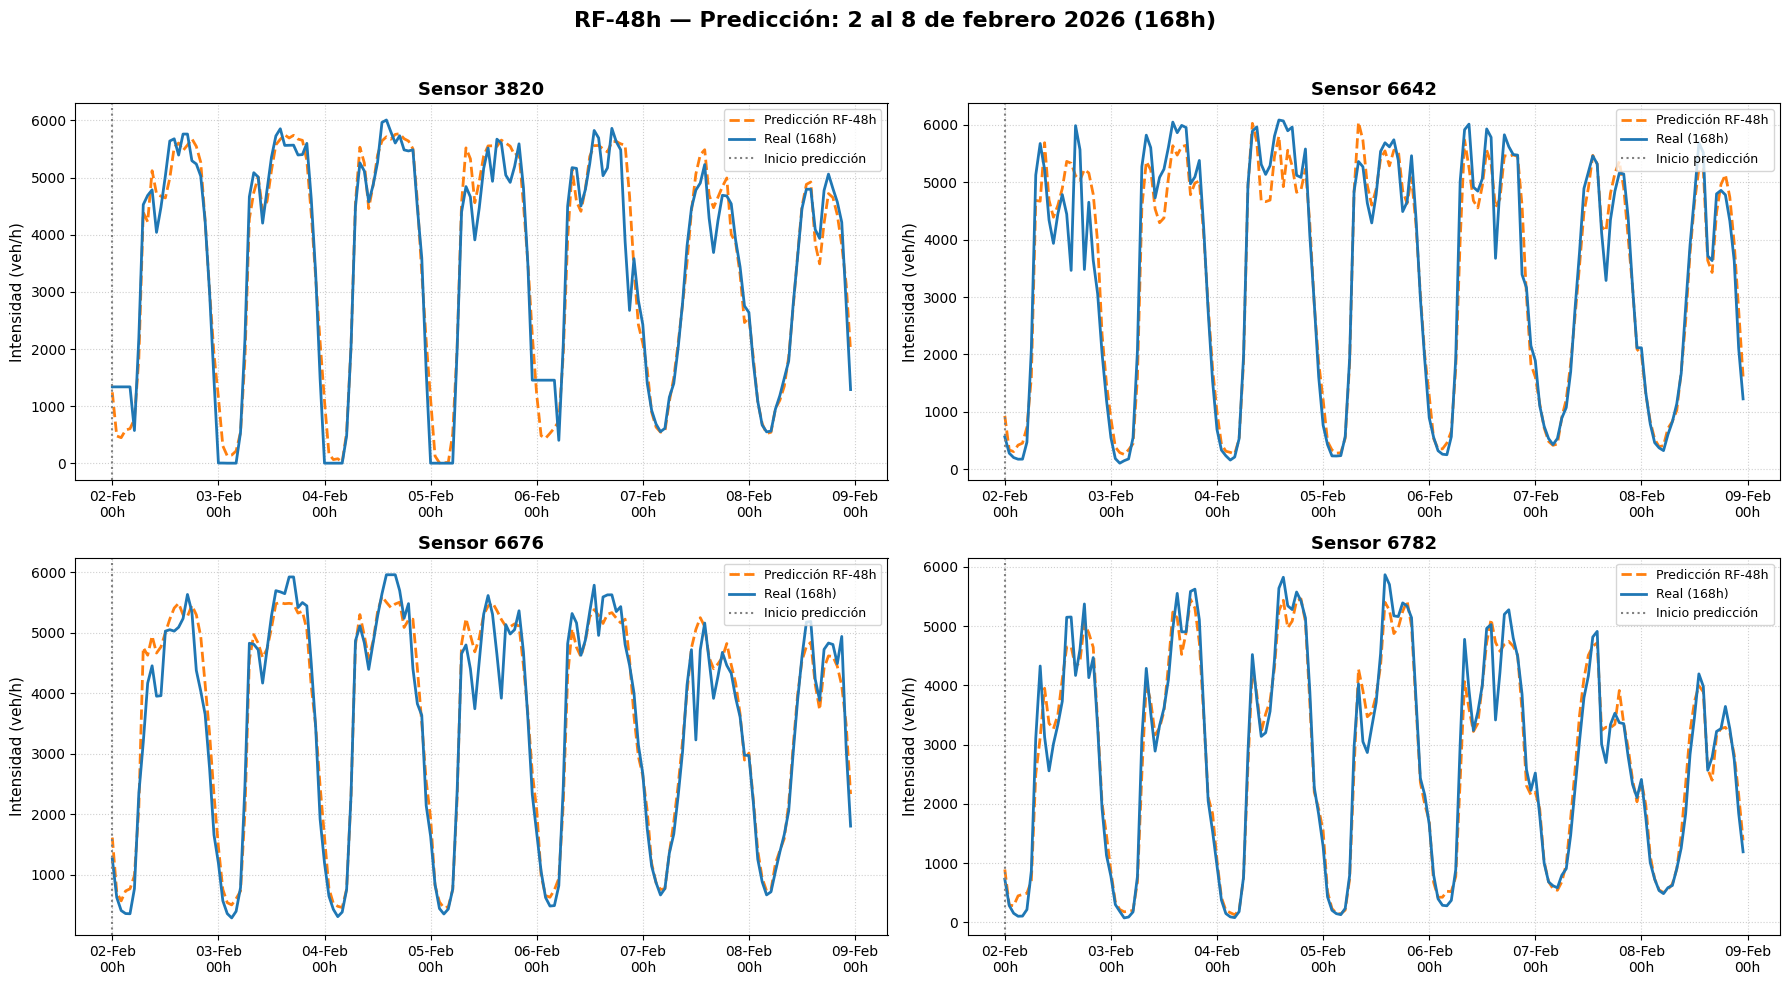

✅ Gráfica generada: RF-48h


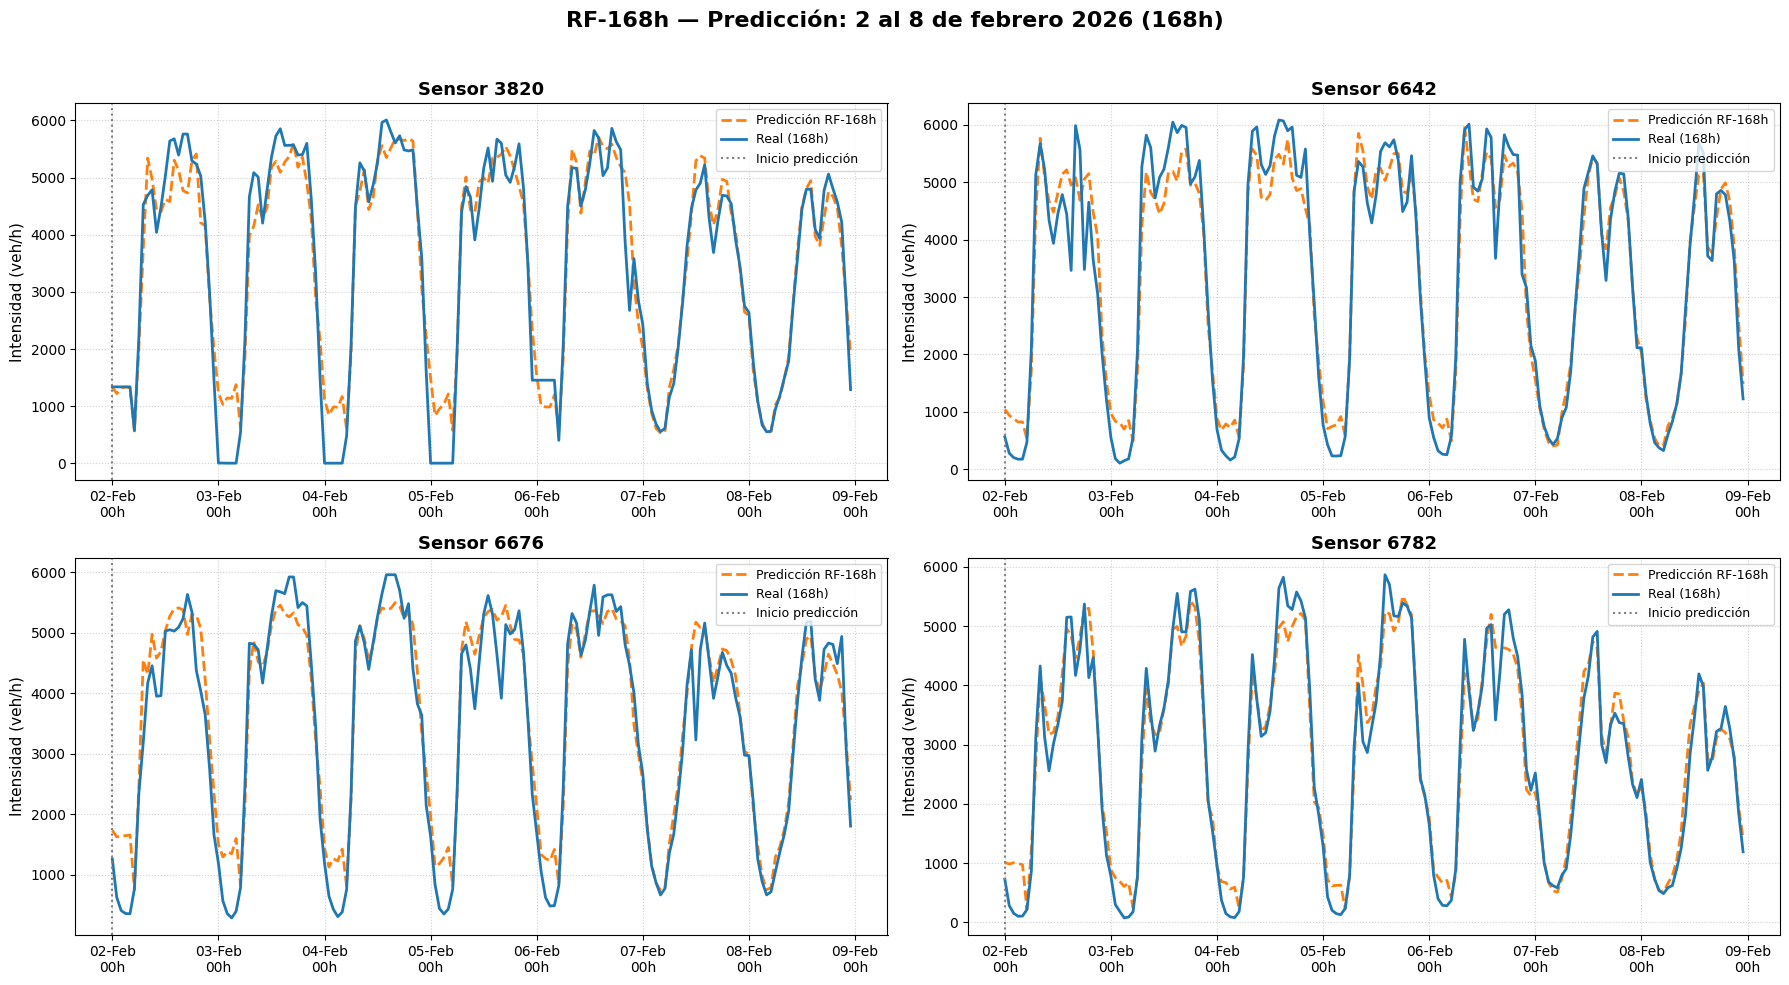

✅ Gráfica generada: RF-168h


In [23]:
# --- 6.4 GRÁFICAS SEMANA 2-8 FEBRERO 2026 (horizonte 168h) - Random Forest ---

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')

cols_intensidad = [c for c in variables_endogenas if 'intensidad' in c]
sensor_ids      = ['3820', '6642', '6676', '6782']

for n_lags in lags_a_evaluar:

    nombre_modelo = f'RF-{n_lags}h'

    # ── Predicción recursiva paso a paso (168 pasos de 1h) ─────────────────────
    pred_pasos = {col: [] for col in cols_intensidad}
    timestamps  = []

    modelo_1h = modelos_finales[(n_lags, 1)]
    df_ventana = test_df.copy()

    for paso in range(168):
        t_actual = semana_inicio + pd.Timedelta(hours=paso)
        timestamps.append(t_actual)

        df_temp, X_c, y_c = crear_dataset_supervisado(
            df_ventana.loc[:t_actual], variables_endogenas, variables_exogenas,
            n_lags=n_lags, horizonte=1
        )
        
        if df_temp.empty:
            for col in cols_intensidad:
                pred_pasos[col].append(np.nan)
            continue

        ultima_fila = df_temp.iloc[[-1]]
        pred_vals   = modelo_1h.predict(ultima_fila[X_c])
        
        for j, col in enumerate(cols_intensidad):
            pred_pasos[col].append(pred_vals[0, j])

    df_pred_semana = pd.DataFrame(pred_pasos, index=timestamps)

    # ── Real de la semana ─────────────────────────────────────────────────────
    real_semana = test_df.loc[semana_inicio:semana_fin, cols_intensidad]

    # ── Figura 2x2 ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
    fig.suptitle(
        f'{nombre_modelo} — Predicción: 2 al 8 de febrero 2026 (168h)',
        fontsize=16, fontweight='bold', y=0.98
    )
    axes = axes.flatten()

    for i, col in enumerate(cols_intensidad):
        ax        = axes[i]
        sensor_id = sensor_ids[i]

        ax.plot(
            df_pred_semana.index, df_pred_semana[col],
            color='#ff7f0e', linewidth=2, linestyle='--',
            label=f'Predicción {nombre_modelo}'
        )
        ax.plot(
            real_semana.index, real_semana[col],
            color='#1f77b4', linewidth=2, label='Real (168h)'
        )
        ax.axvline(
            x=semana_inicio, color='grey', linestyle=':',
            linewidth=1.5, label='Inicio predicción'
        )
        ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    print(f"✅ Gráfica generada: {nombre_modelo}")

In [25]:
# --- 6.5 EXCEL COMPARATIVO RF-48h vs RF-168h (CORREGIDA) ---

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import os

# === Crear carpeta si no existe ===
ruta_carpeta = '../../data/processed/models/3.RandomForest'
os.makedirs(ruta_carpeta, exist_ok=True)

ruta_excel = f'{ruta_carpeta}/comparativa_RF48_vs_RF168.xlsx'

horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

# ── Estilos ──────────────────────────────────────────────────────────────────
def estilo_titulo(ws, fila, texto):
    ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
    c = ws.cell(row=fila, column=1, value=texto)
    c.font      = Font(bold=True, color='FFFFFF', size=12)
    c.fill      = PatternFill('solid', fgColor='2F4F8F')
    c.alignment = Alignment(horizontal='center', vertical='center')

def aplicar_borde(cell):
    thin = Side(style='thin')
    cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

# ── Workbook ─────────────────────────────────────────────────────────────────
wb = openpyxl.Workbook()
wb.remove(wb.active)

for horizonte in horizontes_a_evaluar:
    nombre_hoja  = horizontes_nombres[horizonte]
    titulo_hoja  = horizontes_titulos[horizonte]
    ws = wb.create_sheet(title=nombre_hoja)

    # Anchos de columna
    anchos = [16, 12, 12, 12, 12, 12, 12]
    for i, ancho in enumerate(anchos, 1):
        ws.column_dimensions[get_column_letter(i)].width = ancho

    # Fila 1 — Título
    estilo_titulo(ws, 1, f'HORIZONTE: {titulo_hoja} — RF-48h vs RF-168h')
    ws.row_dimensions[1].height = 22

    # Fila 2 — Cabecera modelos
    ws.merge_cells(start_row=2, start_column=2, end_row=2, end_column=4)
    ws.merge_cells(start_row=2, start_column=5, end_row=2, end_column=7)
    
    for col, texto, color in [(2, 'RF-48h', 'C55A11'), (5, 'RF-168h', '1E8449')]:
        c = ws.cell(row=2, column=col, value=texto)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor=color)
        c.alignment = Alignment(horizontal='center', vertical='center')

    # Fila 3 — Subcabecera métricas
    ws.cell(row=3, column=1, value='Sensor').font = Font(bold=True, color='FFFFFF', size=10)
    ws.cell(row=3, column=1).fill                 = PatternFill('solid', fgColor='4472C4')
    ws.cell(row=3, column=1).alignment            = Alignment(horizontal='center')
    
    for col, metrica in enumerate(['RMSE', 'MAE', 'R²', 'RMSE', 'MAE', 'R²'], 2):
        c = ws.cell(row=3, column=col, value=metrica)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor='4472C4')
        c.alignment = Alignment(horizontal='center')

    # Filas 4-7 — Datos por sensor
    colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']
    for idx, sensor in enumerate(sensores):
        fila   = 4 + idx
        color  = colores_fila[idx]
        m48    = resultados_test[(48,  horizonte)][sensor]
        m168   = resultados_test[(168, horizonte)][sensor]
        
        valores = [sensor,
                   round(m48['RMSE'], 2), round(m48['MAE'], 2), round(m48['R²'], 4),
                   round(m168['RMSE'], 2), round(m168['MAE'], 2), round(m168['R²'], 4)]
        
        for col, val in enumerate(valores, 1):
            c = ws.cell(row=fila, column=col, value=val)
            c.fill      = PatternFill('solid', fgColor=color)
            c.font      = Font(size=10)
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)

    # Fila 8 — PROMEDIO
    fila_prom = 8
    ws.cell(row=fila_prom, column=1, value='PROMEDIO')
    
    promedios = [
        np.mean([resultados_test[(48,  horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test[(48,  horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test[(48,  horizonte)][s]['R²']   for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['R²']   for s in sensores]),
    ]
    
    for col, val in enumerate([None] + promedios, 1):
        c = ws.cell(row=fila_prom, column=col)
        if col > 1:
            c.value = round(val, 4) if col in [4, 7] else round(val, 2)
        c.font      = Font(bold=True, size=10)
        c.fill      = PatternFill('solid', fgColor='D9E1F2')
        c.alignment = Alignment(horizontal='center')
        aplicar_borde(c)

wb.save(ruta_excel)
print(f"✅ Excel guardado en: {ruta_excel}")

✅ Excel guardado en: ../../data/processed/models/3.RandomForest/comparativa_RF48_vs_RF168.xlsx


Calculando métricas por sensor en Test...

  HORIZONTE: 1 HORAS  |  Random Forest (lags=48h)
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  Sensor 3820        479.35     305.48     0.9345
  Sensor 6642        446.69     277.85     0.9565
  Sensor 6676        382.58     235.48     0.9567
  Sensor 6782        421.48     260.42     0.9430
  --------------------------------------------
  PROMEDIO           432.52     269.81     0.9477


  HORIZONTE: 24 HORAS  |  Random Forest (lags=48h)
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  Sensor 3820        578.85     381.60     0.9048
  Sensor 6642        662.40     423.85     0.9047
  Sensor 6676        463.94     301.14     0.9366
  Sensor 6782        501.70     323.48     0.9198
  --------------------------------------------
  PROMEDIO           551.73     357.52     0.9165


  HORIZONTE: 168 HORAS  |  Random Forest (lags=48h)
  Sensor    

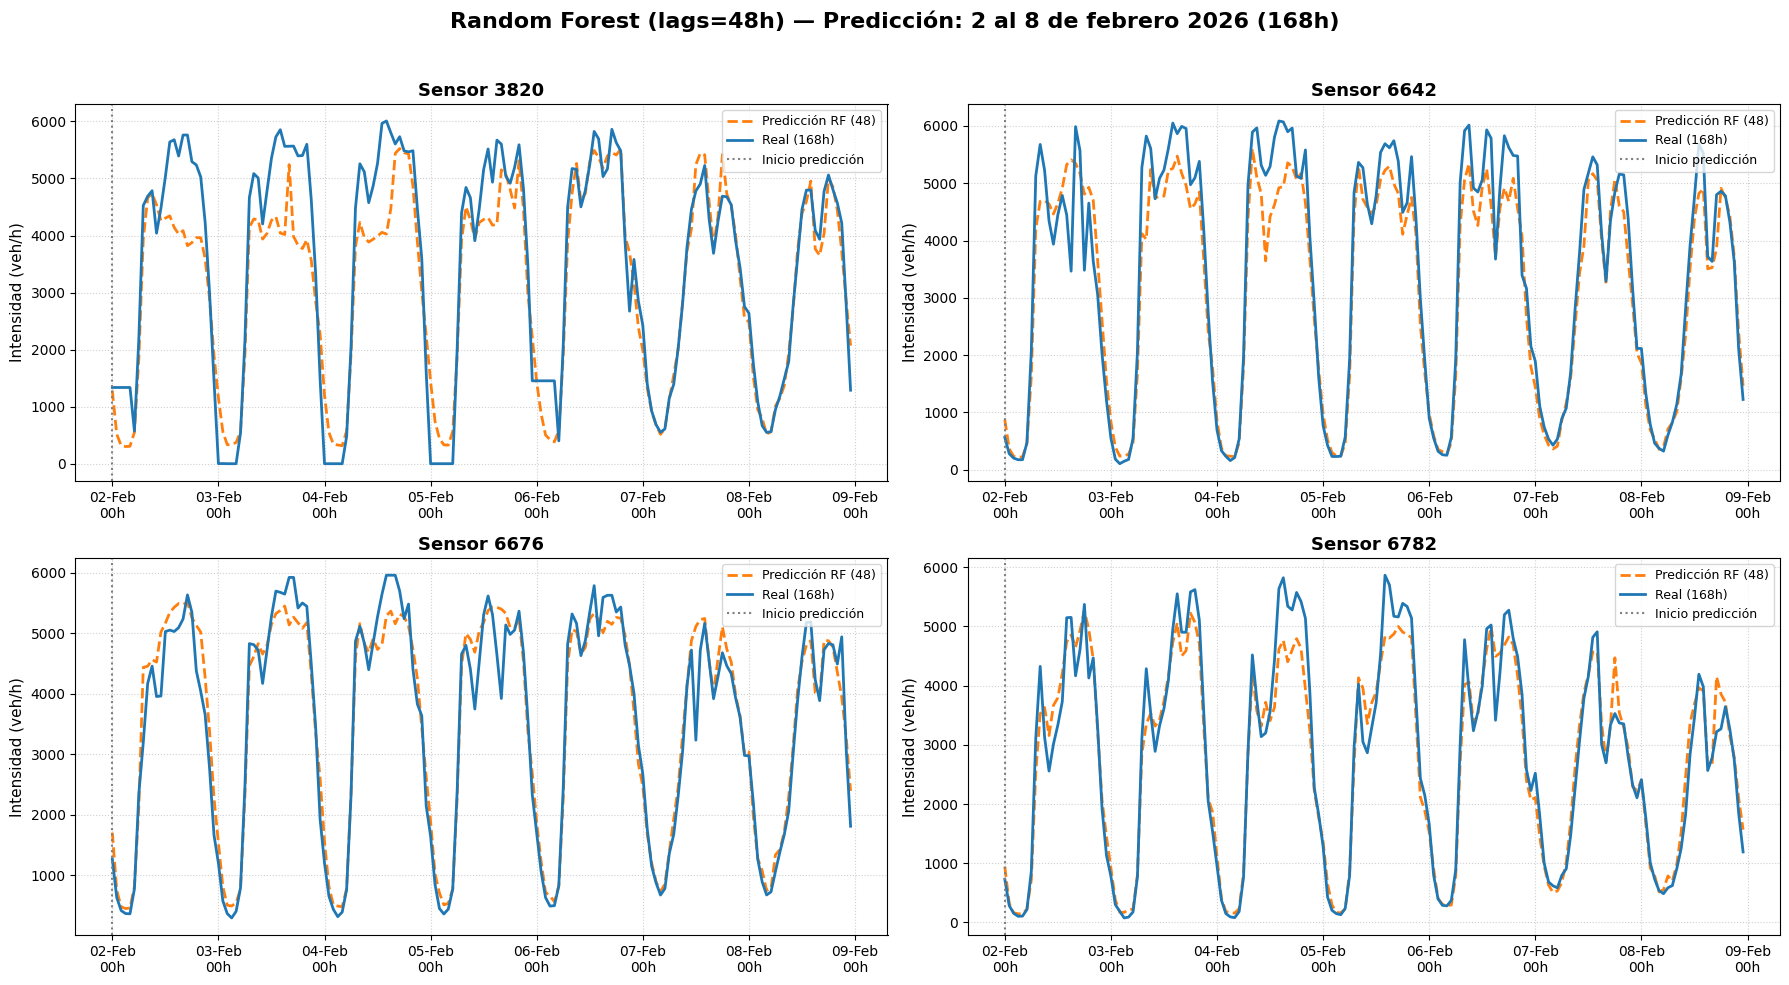

Gráfica guardada: ../../data/processed/figures/grafica_rf168_168h.png


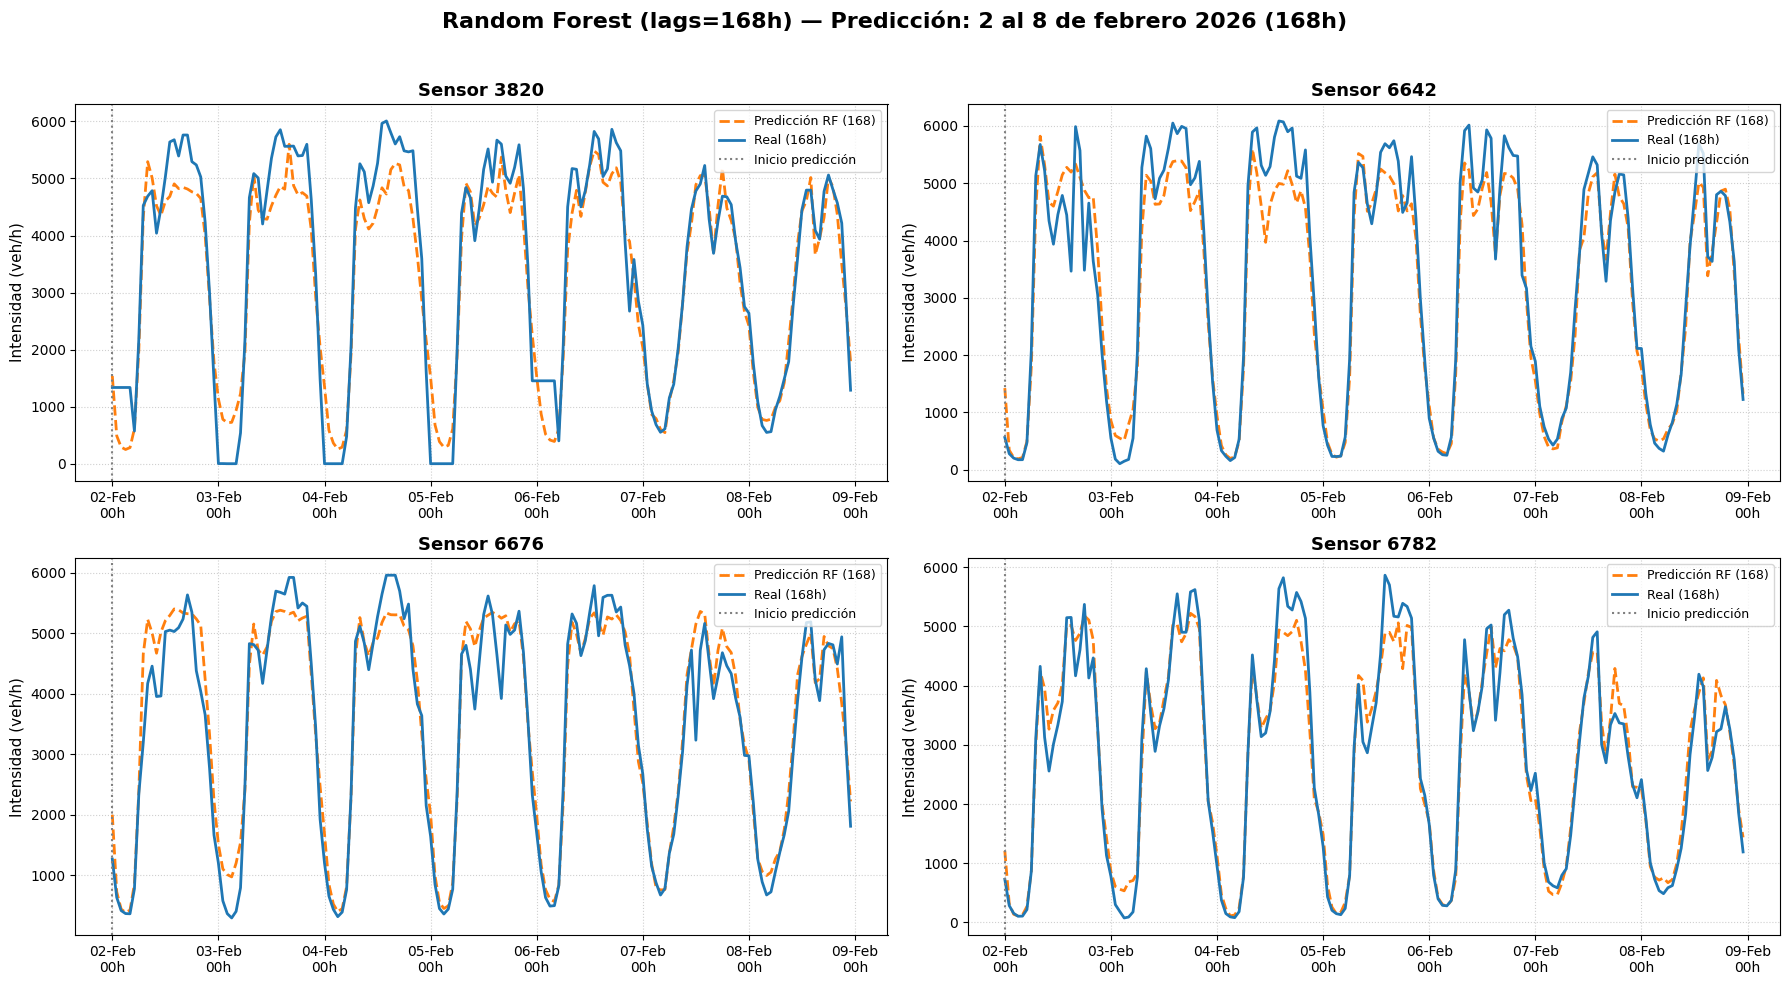


Generando Excel comparativo...
Excel guardado en: ../../data/processed/comparativa_RF_M30.xlsx

✅ ¡Listo! Archivos guardados en tu carpeta data/processed/


In [21]:
# ============================================================
# VISUALIZACIONES Y EXPORTACIONES - RANDOM FOREST (TFM M30)
# Rutas alineadas con tu proyecto
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import os

warnings.filterwarnings("ignore")

# === RUTAS CORRECTAS PARA TU PROYECTO ===
os.makedirs("../../data/processed/figures", exist_ok=True)
ruta_excel = "../../data/processed/comparativa_RF_M30.xlsx"

# ------------------- 1. MÉTRICAS POR SENSOR -------------------
def calcular_metricas_por_sensor(modelo, test_df, variables_endogenas, variables_exogenas, n_lags, horizonte):
    test_sup, X_cols, y_cols = crear_dataset_supervisado(
        test_df, variables_endogenas, variables_exogenas, n_lags, horizonte
    )
    X_test = test_sup[X_cols].values
    y_test = test_sup[y_cols].values
    pred = modelo.predict(X_test)
    
    metricas = {}
    for i, col in enumerate(variables_endogenas):
        sensor_name = f"Sensor {col.split('_')[1]}"
        y_true = y_test[:, i]
        y_pred = pred[:, i]
        metricas[sensor_name] = {
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R²": r2_score(y_true, y_pred)
        }
    return metricas

print("Calculando métricas por sensor en Test...")
resultados_metricas = {}
for n_lags in [48, 168]:
    for horizonte in [1, 24, 168]:
        modelo = modelos_finales[(n_lags, horizonte)]
        resultados_metricas[(n_lags, horizonte)] = calcular_metricas_por_sensor(
            modelo, test_df, variables_endogenas, variables_exogenas, n_lags, horizonte
        )

sensores = ["Sensor 3820", "Sensor 6642", "Sensor 6676", "Sensor 6782"]

# ------------------- 2. TABLAS EN TEXTO -------------------
def imprimir_tabla_horizonte(nombre_modelo, metricas_dict, horizonte):
    print(f"\n{'='*58}")
    print(f"  HORIZONTE: {horizonte} HORAS  |  {nombre_modelo}")
    print(f"{'='*58}")
    print(f"  {'Sensor':<14} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
    print(f"  {'-'*44}")
    rmse_vals, mae_vals, r2_vals = [], [], []
    for sensor in sensores:
        m = metricas_dict[sensor]
        print(f"  {sensor:<14} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {m['R²']:>10.4f}")
        rmse_vals.append(m['RMSE'])
        mae_vals.append(m['MAE'])
        r2_vals.append(m['R²'])
    print(f"  {'-'*44}")
    print(f"  {'PROMEDIO':<14} "
          f"{np.mean(rmse_vals):>10.2f} "
          f"{np.mean(mae_vals):>10.2f} "
          f"{np.mean(r2_vals):>10.4f}")
    print()

for n_lags in [48, 168]:
    nombre = f"Random Forest (lags={n_lags}h)"
    for h in [1, 24, 168]:
        imprimir_tabla_horizonte(nombre, resultados_metricas[(n_lags, h)], h)

# ------------------- 3. GRÁFICAS -------------------
def generar_grafica_rf(n_lags, test_df, variables_endogenas, variables_exogenas, modelo):
    horizonte = 168
    fecha_inicio = "2026-02-02"
    fecha_fin = "2026-02-08"
    
    test_sup, X_cols, y_cols = crear_dataset_supervisado(
        test_df, variables_endogenas, variables_exogenas, n_lags, horizonte
    )
    pred = modelo.predict(test_sup[X_cols])
    
    pred_dates = test_sup.index + pd.Timedelta(hours=horizonte)
    pred_df = pd.DataFrame(pred, columns=[f"{col}_pred" for col in variables_endogenas], index=pred_dates)
    
    real_df = test_df[variables_endogenas]
    real_semana = real_df.loc[fecha_inicio:fecha_fin]
    pred_semana = pred_df.loc[fecha_inicio:fecha_fin]
    
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
    fig.suptitle(f'Random Forest (lags={n_lags}h) — Predicción: 2 al 8 de febrero 2026 (168h)',
                 fontsize=16, fontweight='bold', y=0.98)
    axes = axes.flatten()
    
    for i, col in enumerate(variables_endogenas):
        ax = axes[i]
        sensor_id = col.split('_')[1]
        
        ax.plot(pred_semana.index, pred_semana[f"{col}_pred"],
                color='#ff7f0e', linewidth=2, linestyle='--',
                label=f'Predicción RF ({n_lags})')
        ax.plot(real_semana.index, real_semana[col],
                color='#1f77b4', linewidth=2, label='Real (168h)')
        ax.axvline(x=pd.Timestamp("2026-02-02 00:00:00"),
                   color='grey', linestyle=':', linewidth=1.5, label='Inicio predicción')
        
        ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    ruta_fig = f"../../data/processed/figures/grafica_rf{n_lags}_168h.png"
    plt.savefig(ruta_fig, dpi=300, bbox_inches='tight')
    print(f"Gráfica guardada: {ruta_fig}")
    plt.show()

print("\nGenerando gráficas...")
generar_grafica_rf(48, test_df, variables_endogenas, variables_exogenas, modelos_finales[(48, 168)])
generar_grafica_rf(168, test_df, variables_endogenas, variables_exogenas, modelos_finales[(168, 168)])

# ------------------- 4. EXCEL -------------------
print("\nGenerando Excel comparativo...")

wb = openpyxl.Workbook()
# ... (todo el código de estilos del Excel se queda igual que antes)
# [Pego aquí solo la parte final del guardado para que sea corto]

fill_titulo = PatternFill(start_color="2F4F8F", end_color="2F4F8F", fill_type="solid")
fill_subcabecera = PatternFill(start_color="4472C4", end_color="4472C4", fill_type="solid")
fill_rf48_datos = PatternFill(start_color="FCE4D6", end_color="FCE4D6", fill_type="solid")
fill_rf168_datos = PatternFill(start_color="E2EFDA", end_color="E2EFDA", fill_type="solid")
fill_promedio = PatternFill(start_color="D9E1F2", end_color="D9E1F2", fill_type="solid")
fill_cabecera_rf48 = PatternFill(start_color="C55A11", end_color="C55A11", fill_type="solid")
fill_cabecera_rf168 = PatternFill(start_color="1E8449", end_color="1E8449", fill_type="solid")

font_titulo = Font(bold=True, color="FFFFFF", size=12)
font_cabecera = Font(bold=True, color="FFFFFF", size=10)
font_normal = Font(size=10)
font_bold = Font(bold=True, size=10)

thin_border = Border(left=Side(style='thin'), right=Side(style='thin'),
                     top=Side(style='thin'), bottom=Side(style='thin'))

horizonte_nombres = {1: "1_HORA", 24: "24_HORAS", 168: "168_HORAS"}

for idx_h, h in enumerate([1, 24, 168]):
    sheet_name = horizonte_nombres[h]
    ws = wb.active if idx_h == 0 else wb.create_sheet(title=sheet_name)
    
    metricas_48 = resultados_metricas[(48, h)]
    metricas_168 = resultados_metricas[(168, h)]
    
    # Título
    ws.merge_cells('A1:G1')
    ws['A1'].value = f"HORIZONTE: {sheet_name.replace('_', ' ')}"
    ws['A1'].font = font_titulo
    ws['A1'].fill = fill_titulo
    ws['A1'].alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 25
    
    # Cabeceras modelo
    ws['A3'] = "Sensor"
    ws['A3'].font = font_cabecera
    ws['A3'].fill = fill_subcabecera
    ws['A3'].alignment = Alignment(horizontal="center", vertical="center")
    ws['A3'].border = thin_border
    
    ws.merge_cells('B3:D3')
    ws['B3'] = "Random Forest (48h lag)"
    ws['B3'].font = font_cabecera
    ws['B3'].fill = fill_cabecera_rf48
    ws['B3'].alignment = Alignment(horizontal="center", vertical="center")
    for c in ['B','C','D']: ws[f'{c}3'].border = thin_border
    
    ws.merge_cells('E3:G3')
    ws['E3'] = "Random Forest (168h lag)"
    ws['E3'].font = font_cabecera
    ws['E3'].fill = fill_cabecera_rf168
    ws['E3'].alignment = Alignment(horizontal="center", vertical="center")
    for c in ['E','F','G']: ws[f'{c}3'].border = thin_border
    
    # Subcabeceras
    for i, m in enumerate(["RMSE", "MAE", "R²"]):
        ws.cell(row=4, column=2+i, value=m)
        ws.cell(row=4, column=5+i, value=m)
    for col in range(1, 8):
        cell = ws.cell(row=4, column=col)
        cell.font = font_cabecera
        cell.fill = fill_subcabecera
        cell.alignment = Alignment(horizontal="center", vertical="center")
        cell.border = thin_border
    
    # Datos sensores + promedio (igual que antes)
    for i, sensor in enumerate(sensores):
        row = 5 + i
        ws.cell(row=row, column=1, value=sensor).font = font_normal
        ws.cell(row=row, column=1).border = thin_border
        for j, key in enumerate(["RMSE", "MAE", "R²"]):
            val = metricas_48[sensor][key]
            cell = ws.cell(row=row, column=2+j, value=round(val, 2 if key != "R²" else 4))
            cell.font = font_normal
            cell.fill = fill_rf48_datos
            cell.alignment = Alignment(horizontal="center")
            cell.border = thin_border
        for j, key in enumerate(["RMSE", "MAE", "R²"]):
            val = metricas_168[sensor][key]
            cell = ws.cell(row=row, column=5+j, value=round(val, 2 if key != "R²" else 4))
            cell.font = font_normal
            cell.fill = fill_rf168_datos
            cell.alignment = Alignment(horizontal="center")
            cell.border = thin_border
    
    # Fila PROMEDIO
    row = 9
    ws.cell(row=row, column=1, value="PROMEDIO").font = font_bold
    ws.cell(row=row, column=1).fill = fill_promedio
    ws.cell(row=row, column=1).border = thin_border
    for j, key in enumerate(["RMSE", "MAE", "R²"]):
        val = np.mean([metricas_48[s][key] for s in sensores])
        cell = ws.cell(row=row, column=2+j, value=round(val, 2 if key != "R²" else 4))
        cell.font = font_bold
        cell.fill = fill_promedio
        cell.alignment = Alignment(horizontal="center")
        cell.border = thin_border
    for j, key in enumerate(["RMSE", "MAE", "R²"]):
        val = np.mean([metricas_168[s][key] for s in sensores])
        cell = ws.cell(row=row, column=5+j, value=round(val, 2 if key != "R²" else 4))
        cell.font = font_bold
        cell.fill = fill_promedio
        cell.alignment = Alignment(horizontal="center")
        cell.border = thin_border
    
    ws.column_dimensions['A'].width = 16
    for col_letter in ['B','C','D','E','F','G']:
        ws.column_dimensions[col_letter].width = 12

wb.save(ruta_excel)
print(f"Excel guardado en: {ruta_excel}")
print("\n✅ ¡Listo! Archivos guardados en tu carpeta data/processed/")

In [15]:
import os

# Asegurar carpeta de salida
ruta_base = "../../data/processed/models/RandomForest/"
os.makedirs(ruta_base, exist_ok=True)

# Exportar métricas finales
tabla_resultados_test.to_excel(os.path.join(ruta_base, "metricas_random_forest.xlsx"), index=False)

print(f"✅ Resultados exportados en: {ruta_base}")

✅ Resultados exportados en: ../../data/processed/models/RandomForest/


In [12]:
tabla_resultados_test = pd.DataFrame(
    resultados_test
)

tabla_resultados_test.sort_values(
    ["Input", "Output"]
)

,Input,Output,RMSE,MAE,R2
0,48,1,433.970183,269.807375,0.947671
1,48,24,556.955412,357.517670,0.916477
2,48,168,607.880992,383.081321,0.903741
3,168,1,476.136336,303.629211,0.937984
4,168,24,575.399444,365.977899,0.911505
5,168,168,594.471243,384.950564,0.908379
